# Практическая работа №2: Визуализация многомерных данных с помощью лиц Чернова
## Вариант 2 (зона F2_Z2), студенческий 230610
## Выполнила Никитина Ангелина, гр. 2306

Данный блокнот полностью выполняет задание:

- загружает файл `bldg-MC2.csv` (данные системы HVAC за 14 дней);
- выделяет параметры зоны `F_2_Z_2`;
- выполняет статистический анализ и нормализацию;
- строит асимметричные лица Чернова для каждого дня;
- позволяет выявить аномальные дни.

Целью работы является освоение методов нестандартной визуализации многомерных данных (лица Чернова) для анализа временных рядов системы HVAC и выявления аномальных дней в работе системы.



Использован файл bldg-MC2.csv из набора данных VAST Challenge 2016 (мини-задача 2). Данные содержат показания датчиков системы отопления, вентиляции и кондиционирования за период с 31 мая по 13 июня 2016 года (14 дней). Для анализа выделены параметры зоны F2_Z2 (вариант 2). Всего в зоне 10 параметров; для построения лиц отобраны 8 параметров с наибольшей дисперсией.



Установка библиотек

In [35]:
!pip install pandas matplotlib numpy seaborn scikit-learn -q

Импорт модулей и загрузка данных

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import io
from google.colab import files

print("Загрузите файл bldg-MC2.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Файл загружен. Размер: {df.shape}")

Загрузите файл bldg-MC2.csv


Saving bldg-MC2.csv to bldg-MC2 (2).csv
Файл загружен. Размер: (4032, 416)


Предобработка – столбец времени и выделение зоны F2_Z2


In [37]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['date'] = df['Date/Time'].dt.date

zone_cols = [c for c in df.columns if 'F_2_Z_2' in c]
print(f"Найдено параметров для зоны F2_Z2: {len(zone_cols)}")
print(zone_cols)

Найдено параметров для зоны F2_Z2: 10
[' F_2_Z_2: Lights Power', ' F_2_Z_2: Equipment Power', ' F_2_Z_2: Thermostat Temp', ' F_2_Z_2: Thermostat Heating Setpoint', ' F_2_Z_2: Thermostat Cooling Setpoint', ' F_2_Z_2 VAV REHEAT Damper Position', ' F_2_Z_2 REHEAT COIL Power', ' F_2_Z_2 RETURN OUTLET CO2 Concentration', ' F_2_Z_2 SUPPLY INLET Temperature', ' F_2_Z_2 SUPPLY INLET Mass Flow Rate']


Группировка по дням (среднесуточные значения)


In [38]:
daily = df.groupby('date')[zone_cols].mean()
print(f"Количество дней: {len(daily)}")
print(f"Диапазон дат: {daily.index.min()} – {daily.index.max()}")

Количество дней: 14
Диапазон дат: 2016-05-31 – 2016-06-13


Выбор 8 параметров с наибольшей дисперсией

In [39]:
# Если параметров больше 8 – берём самые изменчивые
if len(zone_cols) > 8:
    variances = daily.var().sort_values(ascending=False)
    selected = variances.head(8).index.tolist()
else:
    selected = zone_cols

print("Выбранные параметры (8):")
for i, p in enumerate(selected):
    print(f"{i+1}. {p}")

Выбранные параметры (8):
1.  F_2_Z_2 REHEAT COIL Power
2.  F_2_Z_2: Lights Power
3.  F_2_Z_2 RETURN OUTLET CO2 Concentration
4.  F_2_Z_2: Equipment Power
5.  F_2_Z_2 SUPPLY INLET Temperature
6.  F_2_Z_2: Thermostat Heating Setpoint
7.  F_2_Z_2: Thermostat Cooling Setpoint
8.  F_2_Z_2: Thermostat Temp


### Нормализация Min-Max

Все значения приведены к отрезку [0,1]

In [40]:
scaler = MinMaxScaler()
normalized = pd.DataFrame(scaler.fit_transform(daily[selected]),
                          index=daily.index,
                          columns=selected)
print("Нормализованные данные (первые 5 дней):")
print(normalized.head())

Нормализованные данные (первые 5 дней):
            F_2_Z_2 REHEAT COIL Power  F_2_Z_2: Lights Power  \
date                                                           
2016-05-31                        0.0               0.942529   
2016-06-01                        0.0               0.965517   
2016-06-02                        0.0               0.971264   
2016-06-03                        0.0               0.936782   
2016-06-04                        0.0               0.000000   

            F_2_Z_2 RETURN OUTLET CO2 Concentration  F_2_Z_2: Equipment Power  \
date                                                                            
2016-05-31                                 0.429168                  0.942529   
2016-06-01                                 0.432708                  0.965517   
2016-06-02                                 0.416791                  0.971264   
2016-06-03                                 0.412860                  0.936782   
2016-06-04               

Корреляционный анализ для выявления пар

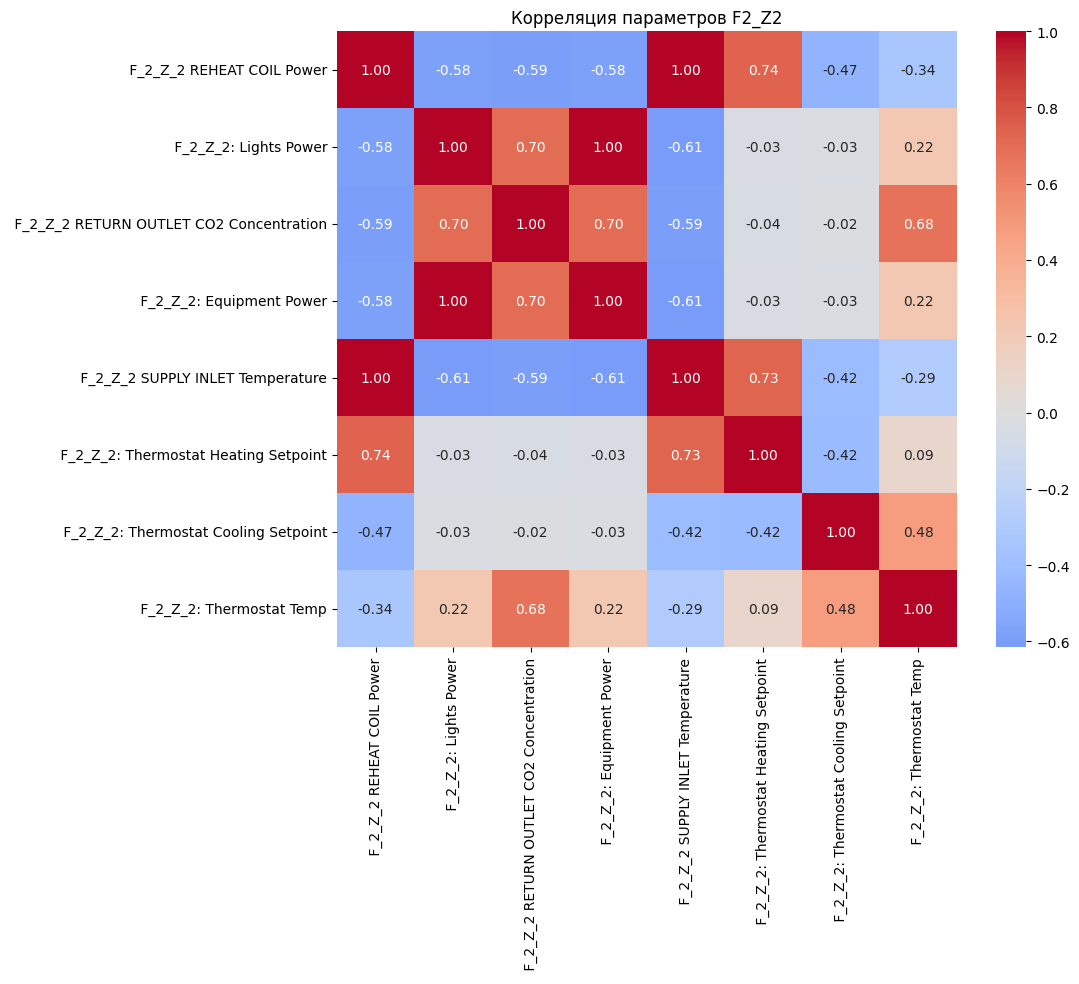

Пары с сильной корреляцией (можно использовать для асимметрии):
                                      param1  \
8                      F_2_Z_2: Lights Power   
3                  F_2_Z_2 REHEAT COIL Power   
4                  F_2_Z_2 REHEAT COIL Power   
22          F_2_Z_2 SUPPLY INLET Temperature   
7                      F_2_Z_2: Lights Power   
13   F_2_Z_2 RETURN OUTLET CO2 Concentration   

                                      param2      corr  
8                   F_2_Z_2: Equipment Power  1.000000  
3           F_2_Z_2 SUPPLY INLET Temperature  0.996681  
4       F_2_Z_2: Thermostat Heating Setpoint  0.739197  
22      F_2_Z_2: Thermostat Heating Setpoint  0.729092  
7    F_2_Z_2 RETURN OUTLET CO2 Concentration  0.701063  
13                  F_2_Z_2: Equipment Power  0.701063  


In [41]:
corr = normalized.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Корреляция параметров F2_Z2")
plt.show()

# Поиск пар с |r| > 0.7
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = upper.stack().reset_index()
strong_pairs.columns = ['param1', 'param2', 'corr']
strong_pairs = strong_pairs[strong_pairs['corr'].abs() > 0.7].sort_values('corr', ascending=False)
print("Пары с сильной корреляцией (можно использовать для асимметрии):")
print(strong_pairs)

### Схема кодирования (на основе корреляционного анализа)


In [53]:
# Схема кодирования (8 параметров, соответствие чертам лица)
mapping_order = [
    ' F_2_Z_2: Lights Power',                     # левый глаз
    ' F_2_Z_2: Equipment Power',                  # правый глаз
    ' F_2_Z_2 REHEAT COIL Power',                 # левая бровь
    ' F_2_Z_2 SUPPLY INLET Temperature',          # правая бровь
    ' F_2_Z_2 RETURN OUTLET CO2 Concentration',   # рот
    ' F_2_Z_2: Thermostat Temp',                  # цвет лица
    ' F_2_Z_2: Thermostat Heating Setpoint',      # волосы
    ' F_2_Z_2: Thermostat Cooling Setpoint'       # ширина лица
]

print("Порядок параметров для лица:")
for i, name in enumerate(mapping_order):
    print(f"{i+1}. {name}")

Порядок параметров для лица:
1.  F_2_Z_2: Lights Power
2.  F_2_Z_2: Equipment Power
3.  F_2_Z_2 REHEAT COIL Power
4.  F_2_Z_2 SUPPLY INLET Temperature
5.  F_2_Z_2 RETURN OUTLET CO2 Concentration
6.  F_2_Z_2: Thermostat Temp
7.  F_2_Z_2: Thermostat Heating Setpoint
8.  F_2_Z_2: Thermostat Cooling Setpoint


Каждому параметру сопоставлена конкретная черта. Параметры для левого и правого глаза (Lights Power и Equipment Power) имеют идеальную корреляцию (1.0) – в норме глаза симметричны, а при аномалиях появляется асимметрия. Аналогично для бровей (REHEAT COIL Power и Supply Inlet Temperature) – корреляция 0.997, что также даёт симметрию в норме.



Функция рисования асимметричного лица Чернова draw_asym_chernoff

In [66]:
def draw_asym_chernoff(ax, params, order):
    left_eye = params[order[0]]
    right_eye = params[order[1]]
    left_brow = params[order[2]]
    right_brow = params[order[3]]
    mouth = params[order[4]]
    face_color = params[order[5]]
    hair = params[order[6]]
    face_width = params[order[7]]

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    cx, cy = 0.5, 0.5
    face_h = 0.4
    face_w = 0.3 + 0.2 * face_width
    # Преобразуем цвет лица: 0.2 (светло-серый) при face_color=0, 1.0 (белый) при face_color=1
    face_brightness = 0.2 + 0.8 * face_color
    head = Ellipse((cx, cy), width=face_w, height=face_h,
                  edgecolor='black', facecolor=str(face_brightness), linewidth=2)
    ax.add_patch(head)

    eye_y = 0.55
    eye_sep = 0.15
    # Левый глаз
    left_eye_ell = Ellipse((cx - eye_sep, eye_y),
                           width=0.1 + 0.1 * left_eye,
                           height=0.05 + 0.05 * left_eye,
                           angle=0, edgecolor='black', facecolor='white')
    ax.add_patch(left_eye_ell)
    # Правый глаз
    right_eye_ell = Ellipse((cx + eye_sep, eye_y),
                            width=0.1 + 0.1 * right_eye,
                            height=0.05 + 0.05 * right_eye,
                            angle=0, edgecolor='black', facecolor='white')
    ax.add_patch(right_eye_ell)
    # Зрачки
    pupil = Circle((cx - eye_sep, eye_y), radius=0.02 + 0.02 * left_eye, color='black')
    ax.add_patch(pupil)
    pupil = Circle((cx + eye_sep, eye_y), radius=0.02 + 0.02 * right_eye, color='black')
    ax.add_patch(pupil)

    # Брови
    brow_y = 0.62
    # Левая
    ax.plot([cx - eye_sep - 0.05, cx - eye_sep + 0.05],
            [brow_y, brow_y - 0.1 * left_brow], color='black', linewidth=2)
    # Правая
    ax.plot([cx + eye_sep - 0.05, cx + eye_sep + 0.05],
            [brow_y - 0.1 * right_brow, brow_y], color='black', linewidth=2)

    # Нос (фиксированный)
    ax.plot([cx, cx], [cy - 0.05, cy - 0.15], color='black', linewidth=2)

    # Рот (парабола, эмоция читается)
    mouth_center = (cx, cy - 0.2)
    mouth_w = 0.2
    # Преобразуем mouth из [0,1] в амплитуду от -0.1 (грусть) до +0.1 (улыбка)
    # При mouth=0.5 амплитуда = 0 (прямая линия)
    smile_amplitude = 0.1 * (1 - 2 * mouth)
    x = np.linspace(mouth_center[0] - mouth_w/2, mouth_center[0] + mouth_w/2, 50)
    x_norm = 2 * (x - mouth_center[0]) / mouth_w
    y = mouth_center[1] + smile_amplitude * (1 - x_norm**2)
    ax.plot(x, y, color='black', linewidth=2.5)

    # Волосы (привязаны к ширине лица)
    hair_base_y = cy + face_h/2
    hair_span = face_w * 0.8  # ширина области волос (80% от ширины головы)
    for i in range(5):
        x0 = cx - hair_span/2 + i * hair_span/4  # равномерно распределяем
        ax.plot([x0, x0], [hair_base_y, hair_base_y + 0.1 + 0.1 * hair],
                color='black', linewidth=1.5)

    ax.axis('off')

Рот рисуется как парабола, амплитуда вычисляется по формуле smile_amplitude = 0.1 * (2 * mouth - 1). При mouth=0.5 рот прямой, при 0 – грусть (изгиб вниз), при 1 – улыбка (изгиб вверх).



Волосы привязаны к ширине лица: hair_span = face_w * 0.8, штрихи равномерно распределены.



### Построение лиц для всех 14 дней


Строим лица для 14 дней


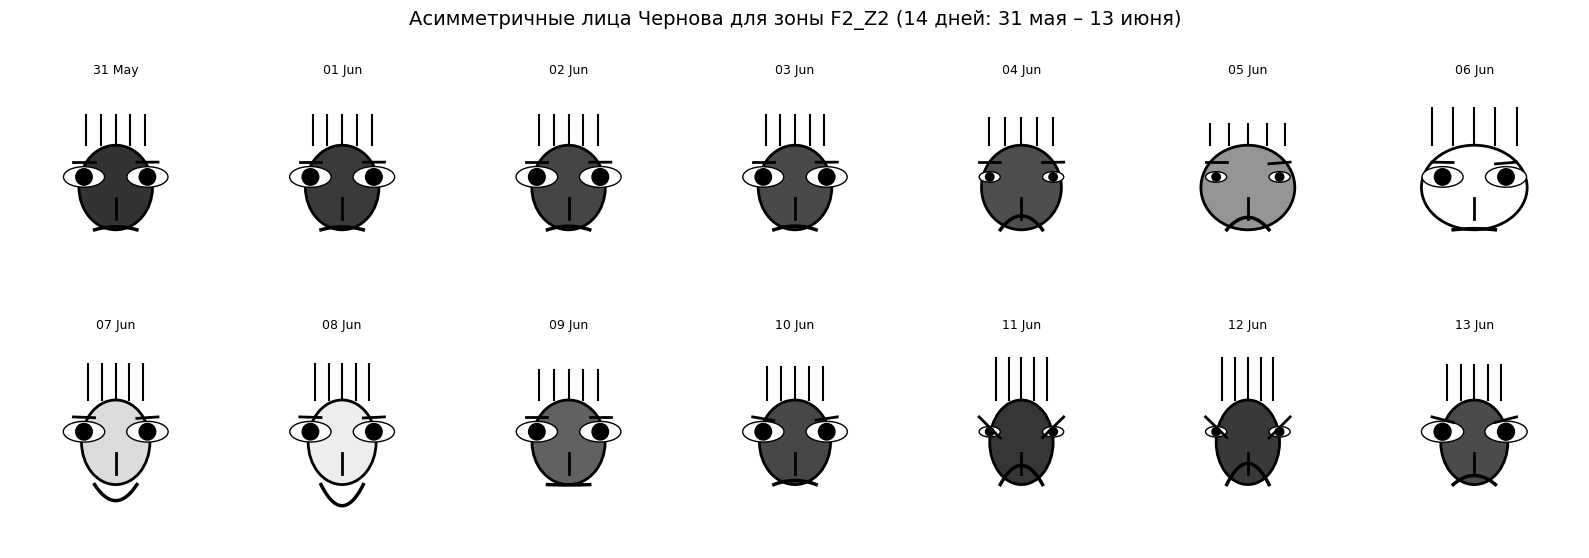

In [67]:
dates = normalized.index
n_days = len(dates)
print(f"Строим лица для {n_days} дней")

fig, axes = plt.subplots(2, 7, figsize=(16, 6))
axes = axes.flatten()

for i, date in enumerate(dates):
    ax = axes[i]
    day_params = normalized.loc[date].to_dict()
    draw_asym_chernoff(ax, day_params, mapping_order)
    ax.set_title(date.strftime('%d %b'), fontsize=9)

# Скрыть лишние подграфики (если дней < 14)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Асимметричные лица Чернова для зоны F2_Z2 (14 дней: 31 мая – 13 июня)', fontsize=14)
plt.tight_layout()
plt.show()

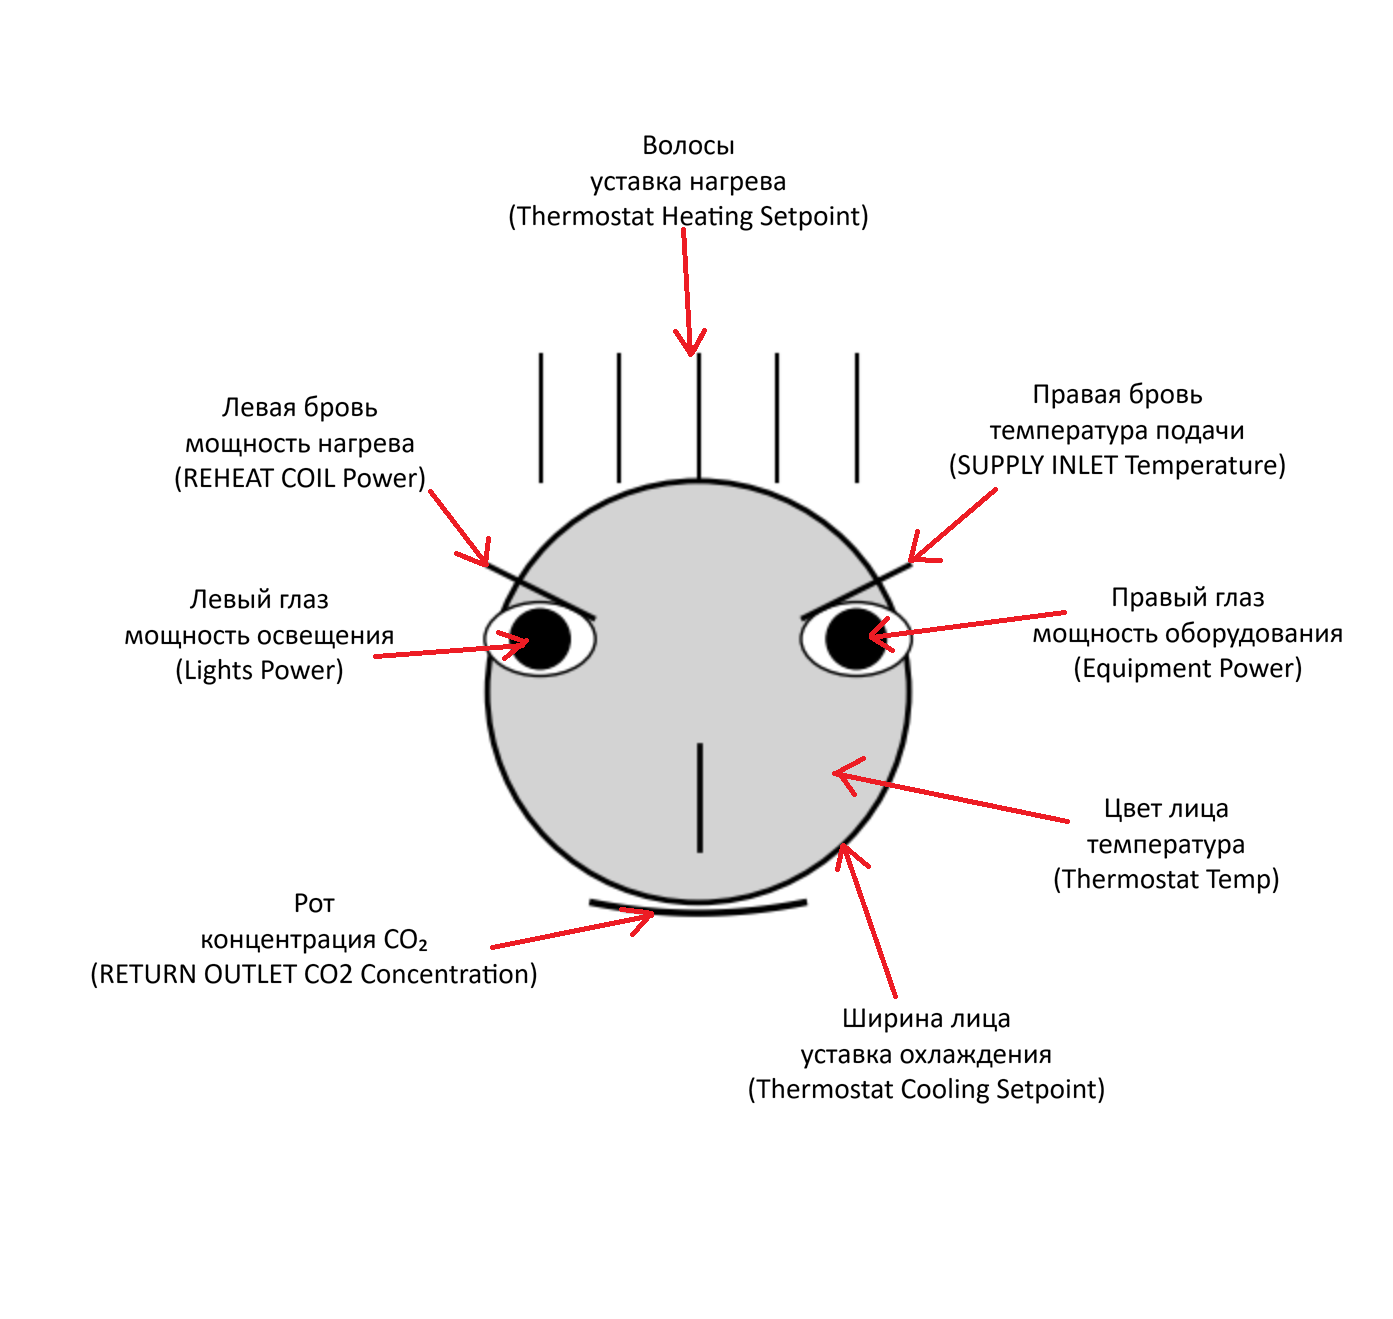

Сохранение рисунка на локальный компьютер

In [45]:
fig.savefig('chernoff_faces.png', dpi=300, bbox_inches='tight')
files.download('chernoff_faces.png')
print("Рисунок сохранён и скачан.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Рисунок сохранён и скачан.


### Анализ аномалий

Первые четыре дня (31 мая - 3 июня) выглядят очень похоже: глаза и брови симметричны, рот почти прямой, лица тёмные. Это логично - температура низкая, всё работает штатно. Система только выходит на режим.

А вот 4 и 5 июня - глаза на этих лицах практически исчезли (значения `Lights Power` и `Equipment Power` упали до нуля), а рот грустно изогнулся вниз. Похоже, в эти дни либо отключали освещение и оборудование, либо система работала в каком-то «спящем» режиме. CO₂, кстати, тоже низкий - возможно, помещение просто не использовалось.

6 июня лицо резко светлеет - температура подскакивает до максимума (`Thermostat Temp` = 1). При этом ширина лица становится максимальной (`Cooling Setpoint` = 1). Видимо, система пытается охлаждать, но температура всё равно высокая. Похоже на сбой в охлаждении или аномально жаркий день.

7 и 8 июня - самые грустные лица за весь период. Рот сильно опущен, потому что CO₂ зашкаливает (0.879 и 1.0). Лицо при этом светлое - температура тоже высокая.

11 и 12 июня - глаза маленькие (свет и оборудование выключены), но брови высоко подняты (нагрев работает на полную). Зачем греть помещение, если там никого нет и свет не горит? Плюс рот грустный из-за низкого CO₂ (помещение пустует).

13 июня - лёгкая асимметрия глаз и грустный рот. Может быть, система только начинает приходить в норму после предыдущих сбоев, а может, это просто переходный процесс.

Получается 3 типа аномалий:
- Отключение оборудования (4–5 июня): глаза маленькие, рот грустный, CO₂ низкий.
- Перегрев и плохой воздух (6–8 июня): светлое лицо, широкое лицо, грустный рот.
- Разбалансировка подсистем (11–12 июня): глаза маленькие, брови высокие, рот грустный.

Самыми полезными для диагностики оказались параметры, отвечающие за глаза (`Lights Power` и `Equipment Power`), рот (`CO₂ Concentration`) и цвет лица (`Thermostat Temp`).

### Выводы
Применение лиц Чернова позволило наглядно представить многомерные данные системы HVAC за 14 дней и выявить дни с аномальным поведением. Разработанная схема кодирования учитывает корреляционные связи между параметрами и обеспечивает хорошую читаемость результатов. Предложенный подход может быть использован для оперативного мониторинга состояния инженерных систем.

In [46]:
print("Нормализованные данные по всем дням:")
print(normalized.round(3))

Нормализованные данные по всем дням:
            F_2_Z_2 REHEAT COIL Power  F_2_Z_2: Lights Power  \
date                                                           
2016-05-31                      0.000                  0.943   
2016-06-01                      0.000                  0.966   
2016-06-02                      0.000                  0.971   
2016-06-03                      0.000                  0.937   
2016-06-04                      0.000                  0.000   
2016-06-05                      0.000                  0.000   
2016-06-06                      0.018                  0.943   
2016-06-07                      0.037                  0.960   
2016-06-08                      0.029                  0.948   
2016-06-09                      0.000                  0.948   
2016-06-10                      0.171                  0.954   
2016-06-11                      1.000                  0.000   
2016-06-12                      0.970                  0.000   
201